# Recovery of heterogeneous mobility processes from temporal contact graphs
This notebook reproduces Figure 6 from the precomputed experimental results.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

CSV_PATH = Path("heterogeneous_contact_errors.csv")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

ORDER_FILTER = None
Y_MIN = 0.0
Y_MAX = None
LEGEND_NCOLS = 3

## Load precomputed data

In [2]:
PANELS = {
    "res1_mean_error": {
        "title": "Error for steady-state vector",
        "ylabel": "Total variation distance",
        "filename": "figure_6a_1"
    },
    "res2_mean_error": {
        "title": "Error for W elements",
        "ylabel": "Total variation distance",
        "filename": "figure_6b_1"
    },
    "res1_sse": {
        "title": "Same-time contact error",
        "ylabel": "Sum of squared errors (SSE)",
        "filename": "figure_6a_2"
    },
    "res2_sse": {
        "title": "Consecutive-time contact error",
        "ylabel": "Sum of squared errors (SSE)",
        "filename": "figure_6b_2"
    }
}


def make_k_label(k):
    return "Steady state" if int(k) == 1_000_001 else f"{int(k):,}"

def load_data(path):
    df = pd.read_csv(path, sep=None, engine="python")
    df.columns = [str(c).strip() for c in df.columns]

    required = {"network", "order", "k", *PANELS}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")

    df = df[["network", "order", "k", *PANELS]].copy()
    df["network"] = df["network"].astype(str)
    df["order"] = pd.to_numeric(df["order"], errors="raise").astype(int)
    df["k"] = pd.to_numeric(df["k"], errors="raise").astype(int)

    for col in PANELS:
        df[col] = pd.to_numeric(df[col], errors="raise")

    df = (
        df.groupby(["network", "order", "k"], as_index=False)[list(PANELS)]
        .mean()
        .sort_values(["network", "order", "k"])
        .reset_index(drop=True)
    )

    if ORDER_FILTER is not None:
        df = df[df["order"] == int(ORDER_FILTER)].copy()

    if df.empty:
        raise ValueError("No data left after filtering")

    df["line_label"] = (
        df["network"]
        + " ("
        + (df["order"] + 1).astype(str)
        + "-order Markov process)"
    )

    return df

df = load_data(CSV_PATH)
df

,network,order,k,res1_mean_error,res2_mean_error,res1_sse,res2_sse,line_label
0,Amsterdam,0,1000,0.685106,0.776816,2.648893e+00,2.770188e+00,Amsterdam (1-order Markov process)
1,Amsterdam,0,10000,0.645188,0.732571,2.155246e+00,1.474752e+00,Amsterdam (1-order Markov process)
2,Amsterdam,0,100000,0.510348,0.652611,7.599712e-01,5.032545e-01,Amsterdam (1-order Markov process)
3,Amsterdam,0,1000000,0.379920,0.437537,6.992129e-02,3.721362e-02,Amsterdam (1-order Markov process)
4,Amsterdam,0,1000001,0.048656,0.054337,5.568543e-06,1.651700e-22,Amsterdam (1-order Markov process)
5,Amsterdam,1,1000,0.785413,0.839155,1.914265e+00,2.132804e+00,Amsterdam (2-order Markov process)
6,Amsterdam,1,10000,0.737202,0.791105,1.996433e-01,2.163918e-01,Amsterdam (2-order Markov process)
7,Amsterdam,1,100000,0.653592,0.723002,1.914033e-02,2.260627e-02,Amsterdam (2-order Markov process)
8,Amsterdam,1,1000000,0.597382,0.628074,1.429714e-03,2.088855e-03,Amsterdam (2-order Markov process)
9,Amsterdam,1,1000001,0.107883,0.127140,8.718829e-07,1.598432e-22,Amsterdam (2-order Markov process)


## Reproduce Figure 6

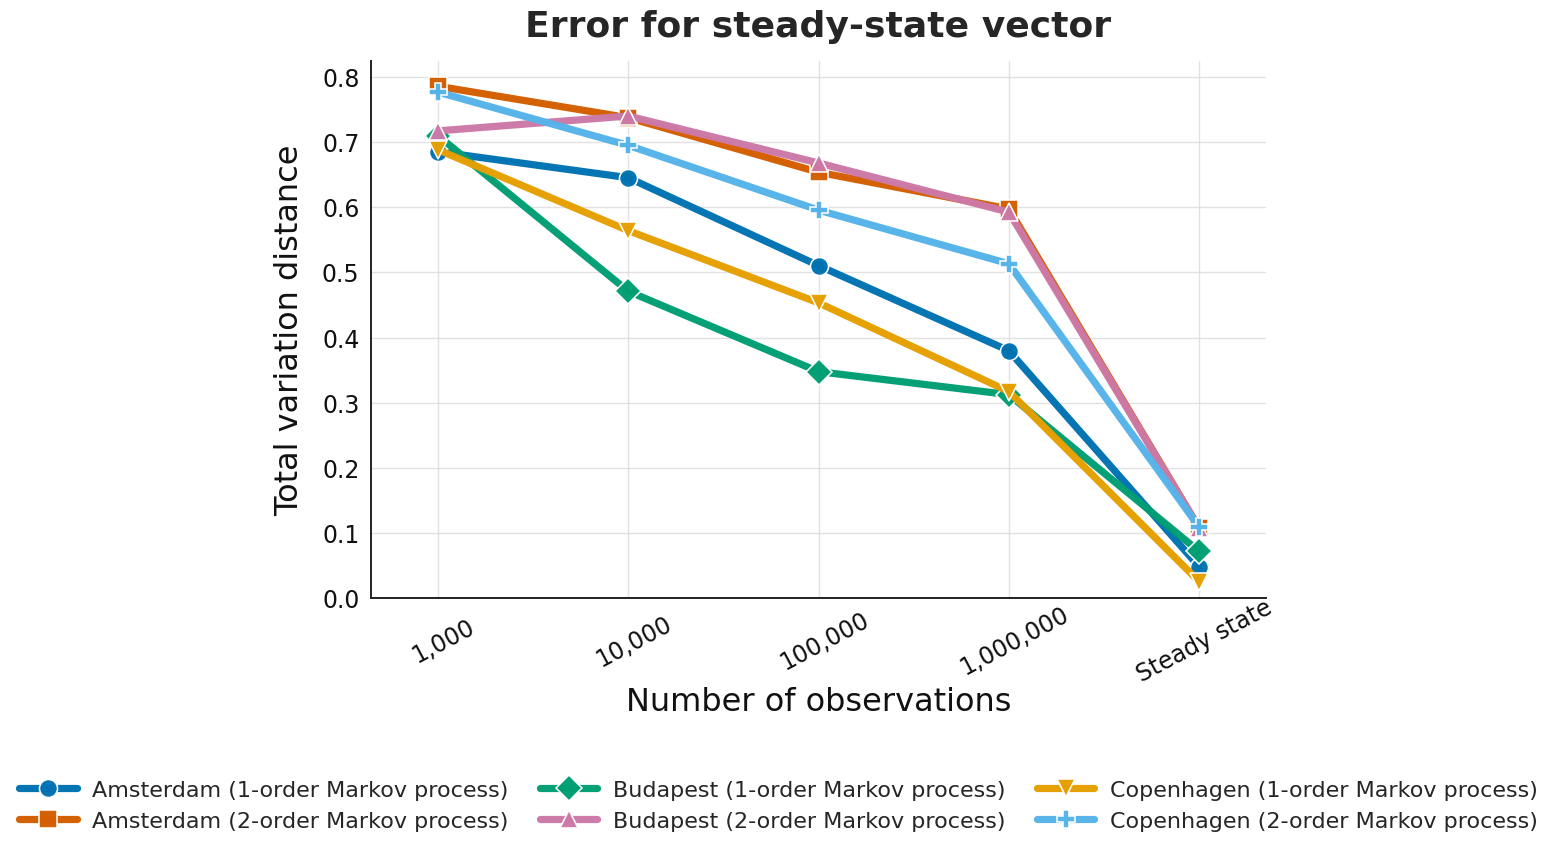

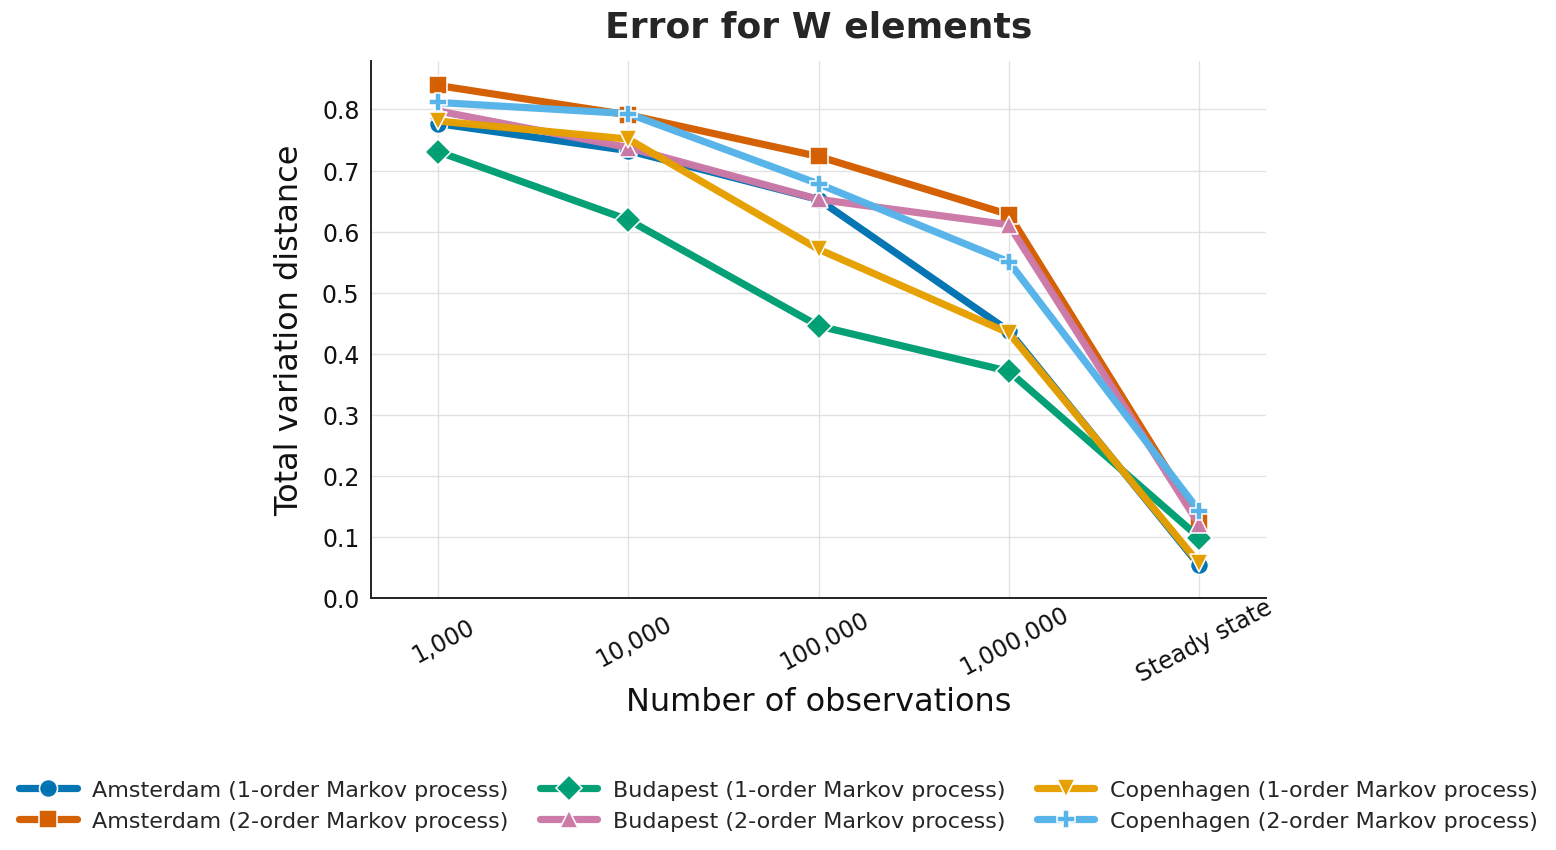

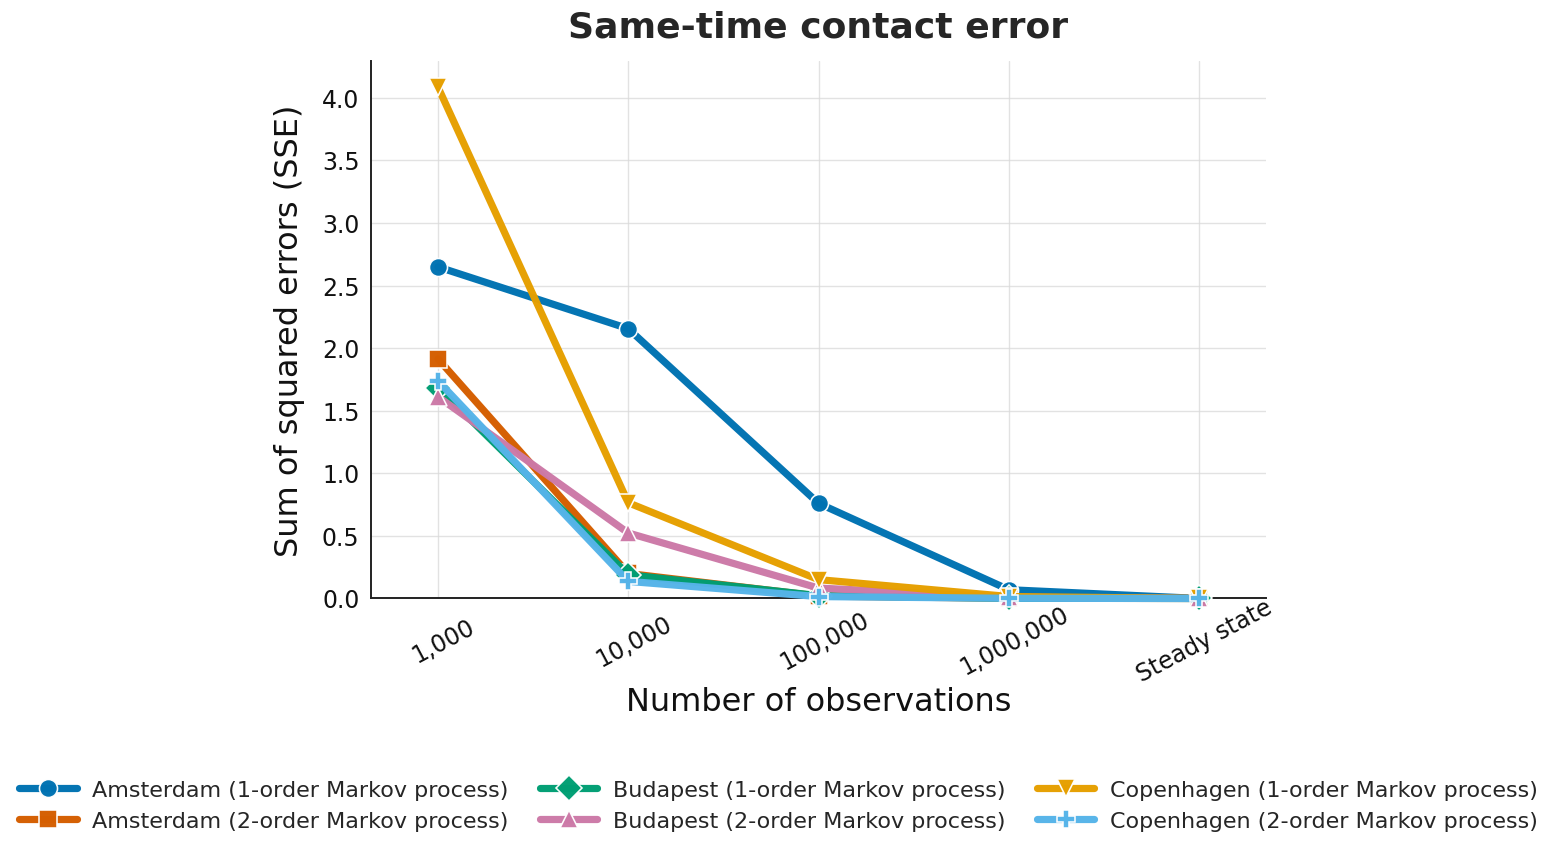

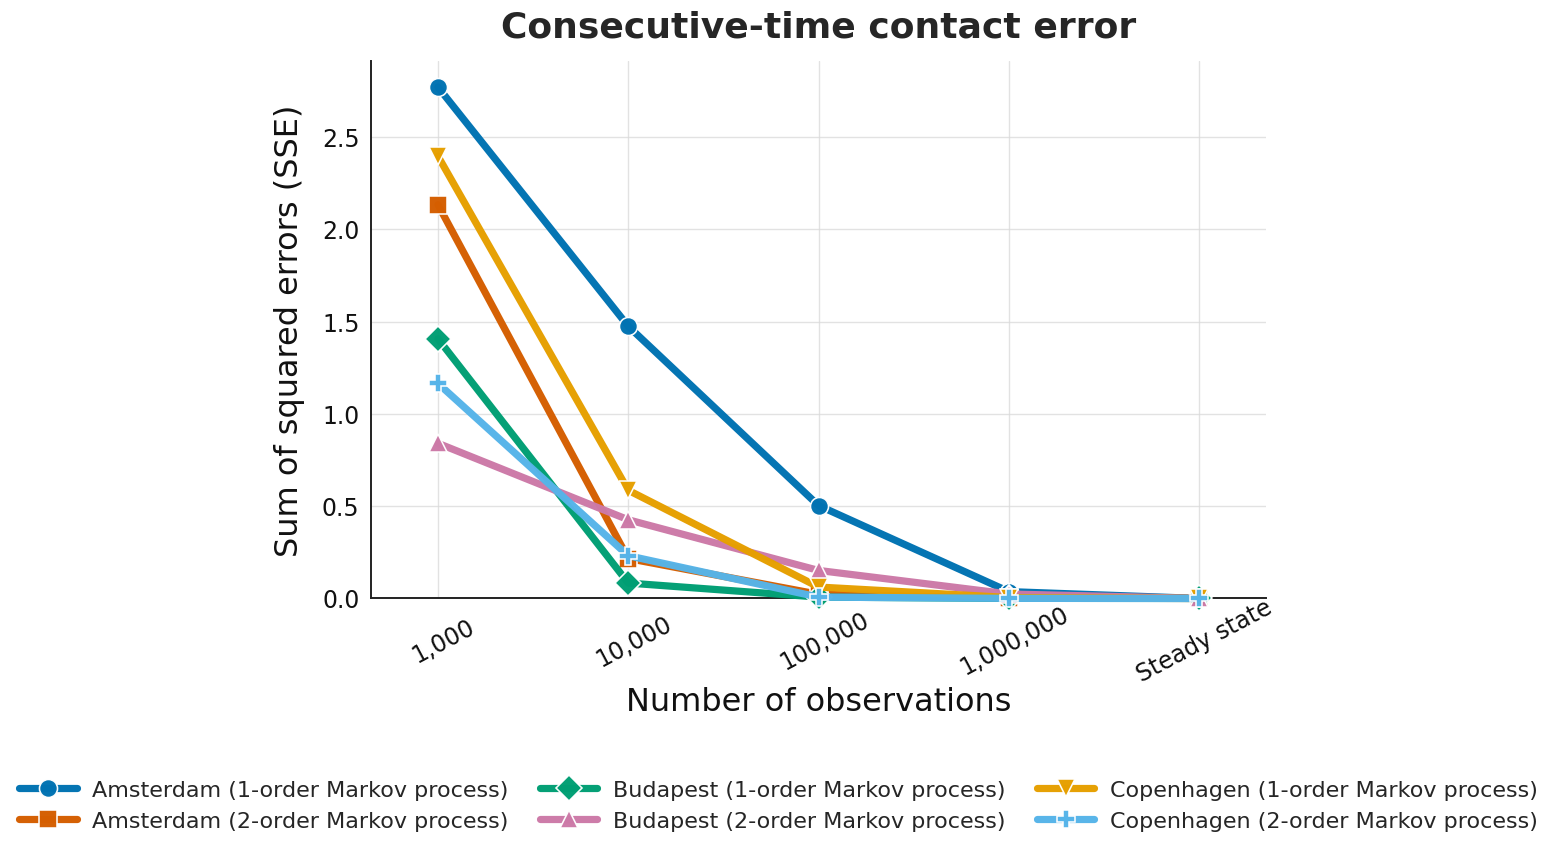

In [3]:
PALETTE = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9", "#000000", "#7F3C8D", "#11A579", "#3969AC", "#E73F74", "#80BA5A"]
MARKERS = ["o", "s", "D", "^", "v", "P", "X", "*", "<", ">", "h", "p"]

sns.set_theme(context="paper", style="white", font_scale=1.45)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.edgecolor": "#222222",
    "axes.linewidth": 1.4,
    "axes.labelcolor": "#111111",
    "xtick.color": "#111111",
    "ytick.color": "#111111"
})


def plot_panel(metric, save=True):
    config = PANELS[metric]

    k_values = sorted(df["k"].unique())
    k_to_pos = {k: i for i, k in enumerate(k_values)}

    plot_df = df.copy()
    plot_df["k_pos"] = plot_df["k"].map(k_to_pos)

    labels = sorted(plot_df["line_label"].unique())

    if len(labels) <= len(PALETTE):
        palette = PALETTE[:len(labels)]
    else:
        palette = sns.color_palette("husl", n_colors=len(labels))

    colors = {label: palette[i] for i, label in enumerate(labels)}

    fig, ax = plt.subplots(figsize=(10.5, 7.5))
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#222222")
    ax.spines["bottom"].set_color("#222222")

    for j, label in enumerate(labels):
        sub = plot_df[plot_df["line_label"] == label].sort_values("k")

        ax.plot(
            sub["k_pos"],
            sub[metric],
            label=label,
            color=colors[label],
            marker=MARKERS[j % len(MARKERS)],
            linewidth=5.2,
            markersize=13.0,
            markeredgecolor="white",
            markeredgewidth=1.15,
            alpha=0.98,
            zorder=3,
            clip_on=False
        )

    x_positions = list(range(len(k_values)))

    ax.set_title(
        config["title"],
        fontsize=26,
        weight="bold",
        pad=18
    )

    ax.set_xlabel(
        "Number of observations",
        fontsize=23,
        labelpad=0
    )

    ax.set_ylabel(
        config["ylabel"],
        fontsize=23,
        labelpad=12
    )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(
        [make_k_label(k) for k in k_values],
        rotation=28,
        ha="center",
        rotation_mode="anchor"
    )

    ax.set_xlim(-0.35, len(k_values) - 0.65)

    if Y_MAX is None:
        ax.set_ylim(bottom=Y_MIN)
    else:
        ax.set_ylim(Y_MIN, Y_MAX)

    ax.tick_params(
        axis="x",
        labelsize=17,
        pad=18,
        length=5,
        width=1.2
    )

    ax.tick_params(
        axis="y",
        labelsize=17,
        length=5,
        width=1.2
    )

    ax.grid(
        True,
        which="major",
        axis="both",
        color="#D9D9D9",
        linewidth=1.0,
        alpha=0.75,
        zorder=0
    )

    handles, legend_labels = ax.get_legend_handles_labels()

    fig.legend(
        handles,
        legend_labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=LEGEND_NCOLS,
        frameon=False,
        fontsize=16,
        handlelength=2.6,
        columnspacing=1.4,
        handletextpad=0.7,
        markerscale=1.0
    )

    fig.tight_layout()

    if save:
        fig.savefig(
            OUTPUT_DIR / f'{config["filename"]}.png',
            dpi=400,
            bbox_inches="tight",
            facecolor="white",
            transparent=False
        )
    plt.show()


plot_panel("res1_mean_error")
plot_panel("res2_mean_error")
plot_panel("res1_sse")
plot_panel("res2_sse")